<a href="https://colab.research.google.com/github/acpotgieter/geog510/blob/Lab-5/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1:  Calculating Distances with Functions
* Define a function calculate_distance that takes two geographic coordinates  (latitude and longitude) and returns the distance between them using the Haversine formula.
*   Use this function to calculate the distance between multiple pairs of coordinates.

In [1]:
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 1.5 MB/s eta 0:00:00


In [2]:
import mapclassify as classify

In [3]:
from math import radians, sin, cos, sqrt, atan2

In [4]:
import numpy as np
import geopandas as gpd

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Create Function

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    )
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

#Calcualte Distance
distance = calculate_distance(22.7648, 143.7383, 38.3857, -174.4738)

print(f"Distance: {distance:.2f} km")

Distance: 4315.77 km


# Exercise 2: Batch Distance Calculation
* Create a function (batch_distance_calculation) that accepts a list of coordinate pairs and returns a list of distances between consecutive pairs.
* Test the function with a list of coordinates representing several cities.

In [7]:
#Create Function

def batch_distance_calculation(coordinate_list):
    distances = []
    for i in range(len(coordinate_list) - 1):
        lat1, lon1 = coordinate_list[i]
        lat2, lon2 = coordinate_list[i + 1]
        distance = calculate_distance(lat1, lon1, lat2, lon2)
        distances.append(distance)
    return distances

#Test
coordinates = [(35.682839, 139.759455), (22.319303, 114.169361), (37.566535, 126.977969)]
distances = batch_distance_calculation(coordinates)

print(f"Distances: {distances}")

Distances: [2884.9336150652716, 2092.3554602490694]


# Exercise 3: Creating and Using a Point Class
* Define a Point class to represent a geographic point with attributes latitude, longitude, and name.
* Add a method distance_to that calculates the distance from one point to another.
* Instantiate several Point objects and calculate the distance between them.

In [8]:
#Define Point Class & Functions
class Point:
    def __init__(self, latitude, longitude, name=None):
        self.latitude = latitude
        self.longitude = longitude
        self.name = name

    def distance_to(self, other_point):
        return calculate_distance(
            self.latitude, self.longitude, other_point.latitude, other_point.longitude
        )

    def __str__(self):
        return f"{self.name or 'Point'} ({self.latitude}, {self.longitude})"



#Test Function
point1 = Point(35.682839, 139.759455, "Tokyo")
point2 = Point(22.319303, 114.169361, "Hong Kong")
distance = point1.distance_to(point2)
print(f"Distance from {point1.name} to {point2.name}: {distance:.2f} km")

Distance from Tokyo to Hong Kong: 2884.93 km


# Exercise 4: Reading and Writing Files
* Write a function read_coordinates that reads a file containing a list of coordinates (latitude, longitude) and returns them as a list of tuples.
* Write another function write_coordinates that takes a list of coordinates and writes them to a new file.
* Ensure that both functions handle exceptions, such as missing files or improperly formatted data.

In [9]:
from os import write
#Create Function
def read_coordinates(filename):
    try:
        with open(filename, "r") as file:
            coordinates = []
            for line in file:
                lat, lon = line.strip().split(",")
                coordinates.append((float(lat), float(lon)))
            return coordinates
    except FileNotFoundError:
        print(f"Error: The File {filename} not found.")
    except ValueError:
        print(f"Error: The file {filename} contains improperly formatted data.")

def write_coordinates(filename, coordinates):
    try:
        with open(filename, "w") as file:
            for lat, lon in coordinates:
                file.write(f"{lat},{lon}\n")
        print(f"Coordinates have been written to {filename}.")
    except Exception as e:
        print(f"An error occurred: {e}")

#Test Function
coordinates = [(35.682839, 139.759455), (22.319303, 114.169361)] #Tokyo and Hong Kong
write_coordinates("output_coordinates.txt", coordinates)
read_coordinates = read_coordinates("output_coordinates.txt")
print(read_coordinates)

Coordinates have been written to output_coordinates.txt.
[(35.682839, 139.759455), (22.319303, 114.169361)]


# Exercise 5: Processing Coordinates from a File
* Create a function that reads coordinates from a file and uses the Point class to create Point objects.
* Calculate the distance between each consecutive pair of points and write the results to a new file.
* Ensure the function handles file-related exceptions and gracefully handles improperly formatted lines.

In [10]:
#Sample Coordinates
sample_coordinates = """35.682839, 139.759455
22.319303, 114.169361
37.5503, 126.9971
35.0116, 135.7681"""

output_file = "coordinates.txt"

try:
    with open(output_file, "w") as file:
        file.write(sample_coordinates)
    print(f"Sample Coordinates file {output_file} has been created successfully.")
except Exception as e:
    print(f"An error occurred while creating the file: {e}")

Sample Coordinates file coordinates.txt has been created successfully.


In [11]:
#Create Function
def process_coordinates(input_file, output_file):
    try:
        points = []
        with open(input_file, "r") as infile:
            for line in infile:
                try:
                    lat, lon = map(float, line.strip().split(","))
                    points.append(Point(lat, lon))
                except ValueError:
                    print(f"Skipping improperly formatted line: {line.strip()}.")
        with open(output_file, "w") as outfile:
            for i in range(len(points) - 1):
                distance = points[i].distance_to(points[i + 1])
                outfile.write(
                    f"Distance to Point {i} to Point {i + 1}: {distance:.2f} km\n"
                )
    except FileNotFoundError:
        print(f"Error: The file {input_file} was not found.")
    except Exception as e:
        print(f"Unexpected error occurred: {e}")

#Test
process_coordinates("coordinates.txt", "distances_output.txt")

# Exercise 6: Exception Handling in Data Processing
* Modify the batch_distance_calculation function to handle exceptions that might occur during the calculation, such as invalid coordinates.
* Ensure the function skips invalid data and continues processing the remaining data.

In [12]:
#Create Function
def batch_distance_calculation_safe(coordinate_list):
    distances = []
    for i in range(len(coordinate_list) - 1):
        try:
            lat1, lon1 = coordinate_list[i]
            lat2, lon2 = coordinate_list[i + 1]
            distance = calculate_distance(lat1, lon1, lat2, lon2)
            distances.append(distance)
        except Exception as e:
            print(
                f"Error calculating distance between {coordinate_list[i] and {coordinate_list[i + 1]}}: {e}"
            )
            distance.append(None)
        return distances

#Test
coordinates = [(35.682839, 139.759455), (22.319303, 114.169361), ("Invalid", 126.9971)]
distances = batch_distance_calculation_safe(coordinates)
print(f"Distances: {distances}")

Distances: [2884.9336150652716]


# Exercise 7: NumPy Array Operations and Geospatial Coordinates
In this exercise, you will work with NumPy arrays representing geospatial coordinates (latitude and longitude) and perform basic array operations.
1. Create a 2D NumPy array containing the latitude and longitude of the following cities: Tokyo (35.6895, 139.6917), New York (40.7128, -74.0060), London (51.5074, -0.1278), and Paris (48.8566, 2.3522).
2. Convert the latitude and longitude values from degrees to radians using np.radians().
3. Calculate the element-wise difference between Tokyo and the other cities’ latitude and longitude in radians.

In [13]:
#Create Array
coordinates = np.array(
    [
        [35.6895, 139.6917],  # Tokyo
        [40.7128, -74.0060],  # New York
        [51.5074, -0.1278],  # London
        [48.8566, 2.3522],  # Paris
    ]
)

#Convert to Radians
coordinates_radians = np.radians(coordinates)
print("Coordinates in radians:\n", coordinates_radians)

#Calculate Tokyo Distances
tokyo_coordinates = coordinates_radians[0]
different_coordinates = coordinates_radians - tokyo_coordinates
print("Difference from Tokyo in radians:\n", different_coordinates)

Coordinates in radians:
 [[ 6.22899283e-01  2.43808010e+00]
 [ 7.10572408e-01 -1.29164837e+00]
 [ 8.98973719e-01 -2.23053078e-03]
 [ 8.52708531e-01  4.10536347e-02]]
Difference from Tokyo in radians:
 [[ 0.          0.        ]
 [ 0.08767312 -3.72972847]
 [ 0.27607444 -2.44031063]
 [ 0.22980925 -2.39702647]]


# Exercise 8: Pandas DataFrame Operations with Geospatial Data
In this exercise, you’ll use Pandas to load and manipulate a dataset containing city population data, and then calculate and visualize statistics.
1. Load the world cities dataset from this URL using Pandas: opengeos/datasets
2. Display the first 5 rows and check for missing values.
3. Filter the dataset to only include cities with a population greater than 1 million.
4. Group the cities by their country and calculate the total population for each country.
5. Sort the cities by population in descending order and display the top 10 cities.

In [14]:
#Load Cities
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
cities_ds = pd.read_csv(url)
cities_ds.head()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


In [15]:
#Check for missing values
print(cities_ds.isnull().sum())

id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64


In [16]:
#Filter cities
pop_cities = cities_ds[cities_ds["population"] > 1_000_000]
pop_cities.head()

,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000


In [17]:
#Grouped cities by countries with population
population_by_country = (
    pop_cities.groupby("country")["population"].sum().reset_index()
)
population_by_country

,country,population
0,AFG,3277000
1,AGO,6272900
2,ARE,1379000
3,ARG,15450000
4,ARM,1102000
...,...,...
105,VNM,11661000
106,YEM,2008000
107,ZAF,11738000
108,ZMB,1328000


In [18]:
#Countries sorted by population, top 10
pop_top10 = pop_cities.sort_values("population", ascending=False).head(10)
pop_top10

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


# Exercise 9: Creating and Manipulating GeoDataFrames with GeoPandas
This exercise focuses on creating and manipulating GeoDataFrames, performing spatial operations, and visualizing the data.
1. Load the New York City building dataset from the GeoJSON file using GeoPandas: opengeos/datasets
2. Create a plot of the building footprints and color them based on the building height (use the height_MS column).
3. Create an interactive map of the building footprints and color them based on the building height (use the height_MS column).
4. Calculate the average building height (use the height_MS column).
5. Select buildings with a height greater than the average height.
6. Save the GeoDataFrame to a new GeoJSON file.

In [19]:
#Load dataset
url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
nyc_build = gpd.read_file(url)
nyc_build.head()

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."


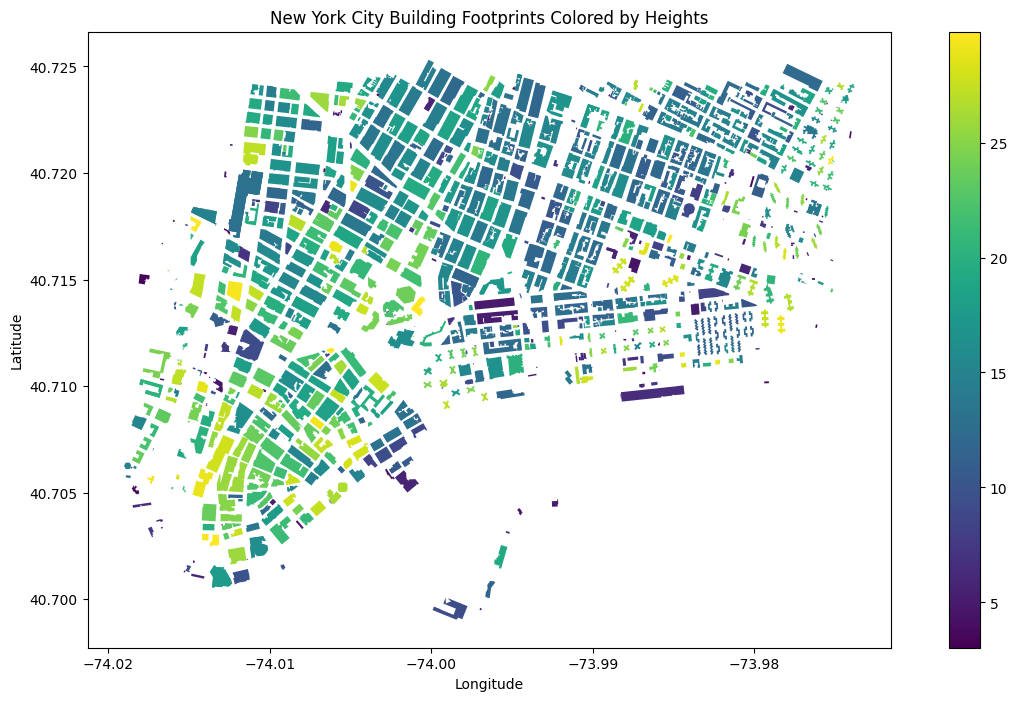

In [20]:
#Create plot
nyc_build.plot(column="height_MS", cmap="viridis", legend=True, figsize=(15, 8))
plt.title("New York City Building Footprints Colored by Heights")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [21]:
#Create interactive map
nyc_build.explore(column="height_MS", cmap="viridis", tooltip=["height_MS"], legend=True)

In [22]:
#Calculate average building height
average_height = nyc_build["height_MS"].mean()
print(f"Average Building Height in New York City: {average_height:.2f} meters")

Average Building Height in New York City: 15.45 meters


In [23]:
#Buildings greater than average
tall_build = nyc_build[nyc_build["height_MS"] > average_height]
tall_build.head()

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."


In [24]:
#Save as GeoJSON file
output_file = "tall_build.geojson"
tall_build.to_file(output_file, driver="GeoJSON")
print(f"Filtered Dataset to has been saved to {output_file}")

Filtered Dataset to has been saved to tall_build.geojson


# Exercise 10: Combining NumPy, Pandas, and GeoPandas
This exercise requires you to combine the power of NumPy, Pandas, and GeoPandas to analyze and visualize spatial data.
1. Use Pandas to load the world cities dataset from this URL: opengeos/datasets
2. Filter the dataset to include only cities with latitude values between -40 and 60 (i.e., cities located in the Northern Hemisphere or near the equator).
3. Create a GeoDataFrame from the filtered dataset by converting the latitude and longitude into geometries.
4. Reproject the GeoDataFrame to the Mercator projection (EPSG:3857).
5. Calculate the distance (in meters) between each city and the city of Paris.
6. Plot the cities on a world map, coloring the points by their distance from Paris.

In [25]:
#Load dataset
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
cities_ds = pd.read_csv(url)
cities_ds.head()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


In [26]:
#Filter cities
filtered_cities = cities_ds[
    (cities_ds["latitude"] > -40) & (cities_ds["latitude"] < 60)
]

In [27]:
#Create GeoDataFrame
filtered_gdf = gpd.GeoDataFrame(
    filtered_cities,
    geometry=gpd.points_from_xy(
        filtered_cities["longitude"], filtered_cities["latitude"]
    ),
    crs="EPSG:3857"
)

In [28]:
#Reproject
filtered_gdf = filtered_gdf.to_crs(epsg=3857)

In [29]:
#Calculate distance
paris_coordinates = filtered_gdf[filtered_gdf["name"] == "Paris"].geometry.iloc[0]
filtered_gdf["distance_to_paris"] = filtered_gdf.geometry.distance(paris_coordinates)

<function matplotlib.pyplot.show(close=None, block=None)>

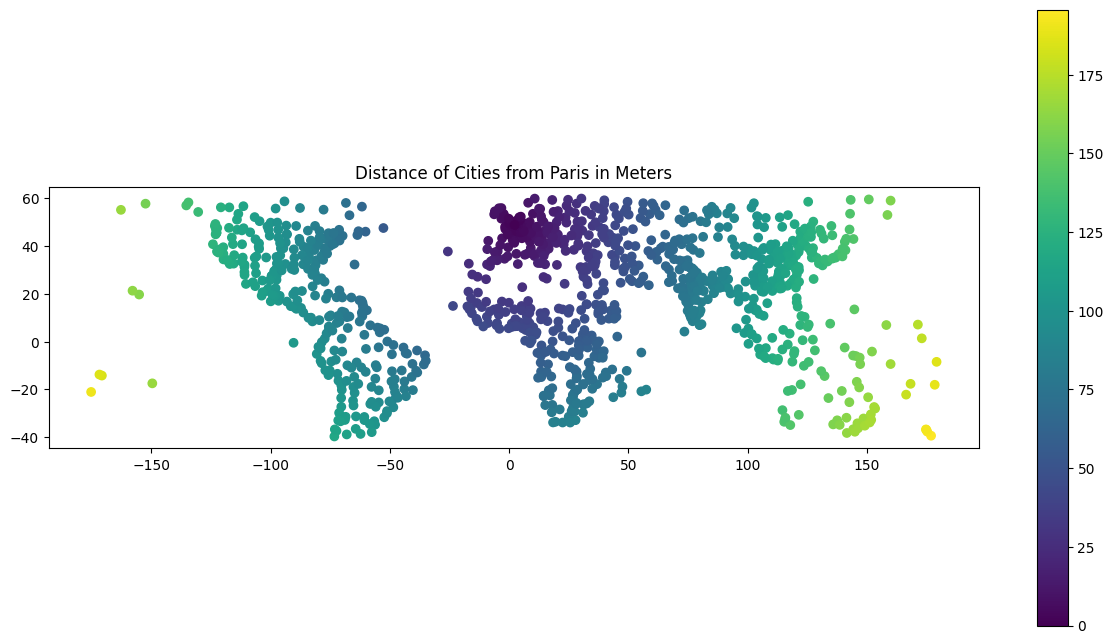

In [30]:
#Plot cities colored by distance
filtered_gdf.plot(
    column="distance_to_paris", legend=True, figsize=(15, 8)
)
plt.title("Distance of Cities from Paris in Meters")
plt.show